In [ ]:
# Imports & Global Configuration
import os
import json
import shutil
import re
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, Dataset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import copy
import random
import time
from collections import deque, defaultdict
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


plt.style.use('default')
sns.set_theme(style='whitegrid')


plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.edgecolor': 'white',
    'axes.edgecolor': '#666666',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
})

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    drive = None
    IN_COLAB = False

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# FL Hyperparameters
NUM_CLIENTS      = 100
NUM_ROUNDS       = 100
LOCAL_EPOCHS     = 3
LOCAL_LR         = 0.01
LOCAL_BATCH_SIZE = 32
K_DEFAULT        = 10        
WINDOW_SIZE      = 15        

# Non-IID Partition Config
SHARDS_PER_CLIENT = 4        
PARTITION_MODE    = "shard"   

# Drift Schedule (4 drifts each) 
LABEL_DRIFT_ROUNDS   = [20, 40, 60, 80]   
FEATURE_DRIFT_ROUNDS  = [20, 40, 60, 80]   

# Feature drift experiment settings
LABEL_WINDOW_VALUES   = [5, 10, 15]       
FEATURE_WINDOW_VALUES  = [5, 10, 15]       


Using device: cuda


In [ ]:
# Drive checkpoint setup and persistence helpers

if IN_COLAB and drive is not None:
    try:
        drive.mount("/content/drive", force_remount=False)
        BASE_SAVE_DIR = Path("/content/drive/MyDrive/SW_ShUCB_nonIID_checkpoints")
    except Exception as e:
        print("Drive mount failed, falling back to local folder:", e)
        BASE_SAVE_DIR = Path("./SW_ShUCB_nonIID_checkpoints")
else:
    BASE_SAVE_DIR = Path("./SW_ShUCB_nonIID_checkpoints")

BASE_SAVE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = BASE_SAVE_DIR / "results"
PLOTS_DIR = BASE_SAVE_DIR / "plots"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Checkpoint folder:", BASE_SAVE_DIR)
print("Results folder    :", RESULTS_DIR)
print("Plots folder      :", PLOTS_DIR)

def safe_name(text):
    text = re.sub(r'[^A-Za-z0-9_.-]+', '_', str(text))
    return text.strip('_') or "experiment"

def exp_dir(selector_name, drift_type, k, window_size, num_rounds=NUM_ROUNDS):
    d = RESULTS_DIR / (
        f"{safe_name(selector_name)}__{drift_type}__K{k}__W{window_size}__R{num_rounds}"
    )
    d.mkdir(parents=True, exist_ok=True)
    return d

def checkpoint_path(d):
    return d / "checkpoint.pt"

def history_path(d):
    return d / "history.json"

def metadata_path(d):
    return d / "metadata.json"

def save_history(d, payload):
    try:
        with open(history_path(d), "w") as f:
            json.dump(payload, f)
    except Exception as e:
        print("Warning: failed to save history:", e)

def load_history(d):
    p = history_path(d)
    if not p.exists():
        return None
    try:
        with open(p, "r") as f:
            return json.load(f)
    except Exception:
        return None

def save_metadata(d, metadata):
    try:
        with open(metadata_path(d), "w") as f:
            json.dump(metadata, f)
    except Exception as e:
        print("Warning: failed to save metadata:", e)

def load_metadata(d):
    p = metadata_path(d)
    if not p.exists():
        return None
    try:
        with open(p, "r") as f:
            return json.load(f)
    except Exception:
        return None

def selector_to_state(selector):
    state = {"class_name": selector.__class__.__name__}
    if hasattr(selector, "selection_counts"):
        state["selection_counts"] = np.asarray(selector.selection_counts).tolist()
    if hasattr(selector, "t"):
        state["t"] = int(selector.t)
    if hasattr(selector, "reward_windows"):
        state["reward_windows"] = {
            int(k): list(v) for k, v in selector.reward_windows.items()
        }
    return state

def selector_from_state(selector, state):
    if not state:
        return selector

    if hasattr(selector, "selection_counts") and "selection_counts" in state:
        selector.selection_counts = np.array(state["selection_counts"], dtype=np.int64)
    if hasattr(selector, "t") and "t" in state:
        selector.t = int(state["t"])
    if hasattr(selector, "reward_windows") and "reward_windows" in state:
        selector.reward_windows = defaultdict(deque)
        for k, vals in state["reward_windows"].items():
            selector.reward_windows[int(k)] = deque(vals, maxlen=getattr(selector, "W", WINDOW_SIZE))
    return selector

def save_rng_state():
    
    cpu_state = torch.get_rng_state().cpu()
    state = {
        "torch": cpu_state.tolist(),
        "numpy": np.random.get_state(),
        "random": random.getstate(),
    }
    if torch.cuda.is_available():
        cuda_states = []
        for s in torch.cuda.get_rng_state_all():
            cuda_states.append(s.cpu().tolist() if hasattr(s, "cpu") else list(s))
        state["torch_cuda_all"] = cuda_states
    return state

def _to_byte_tensor(x):
    if isinstance(x, torch.Tensor):
        if x.dtype != torch.uint8:
            x = x.to(dtype=torch.uint8)
        return x.cpu().contiguous()
    if isinstance(x, np.ndarray):
        return torch.tensor(x, dtype=torch.uint8)
    if isinstance(x, (list, tuple)):
        return torch.tensor(list(x), dtype=torch.uint8)
   
    return torch.tensor(x, dtype=torch.uint8)

def load_rng_state(state):
    if not state:
        return

    try:
        torch_state = state.get("torch")
        if torch_state is not None:
            torch.set_rng_state(_to_byte_tensor(torch_state))
    except Exception as e:
        print(" Warning: could not restore torch RNG state:", e)

    try:
        np_state = state.get("numpy")
        if np_state is not None:
            # Older checkpoints may store tuples as lists after JSON conversion.
            if isinstance(np_state, list) and len(np_state) == 5:
                np_state = (np_state[0], np.array(np_state[1], dtype=np.uint32), np_state[2], np_state[3], np_state[4])
            np.random.set_state(np_state)
    except Exception as e:
        print(" Warning: could not restore NumPy RNG state:", e)

    try:
        py_state = state.get("random")
        if py_state is not None:
            random.setstate(py_state)
    except Exception as e:
        print(" Warning: could not restore Python random state:", e)

   
    if torch.cuda.is_available() and "torch_cuda_all" in state:
        try:
            cuda_states = [_to_byte_tensor(s) for s in state["torch_cuda_all"]]
            torch.cuda.set_rng_state_all(cuda_states)
        except Exception as e:
            print(" Warning: could not restore CUDA RNG state:", e)

def save_dataframe(df, filename):
    path = RESULTS_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved table to {path}")
    return path

def load_checkpoint_bundle(d):
    p = checkpoint_path(d)
    if not p.exists():
        return None
    try:
        return torch.load(p, map_location=DEVICE, weights_only=False)
    except Exception as e:
        print(" Warning: checkpoint load failed:", e)
        return None

def save_checkpoint_bundle(d, model, selector, metrics, completed_rounds,
                           drift_type, drift_rounds, selector_name, K, num_rounds):
    payload = {
        "model_state_dict": model.state_dict(),
        "selector_state": selector_to_state(selector),
        "metrics": metrics,
        "completed_rounds": int(completed_rounds),
        "drift_type": drift_type,
        "drift_rounds": list(drift_rounds),
        "selector_name": selector_name,
        "K": int(K),
        "num_rounds": int(num_rounds),
        "rng_state": save_rng_state(),
    }
    torch.save(payload, checkpoint_path(d))

    save_history(d, {
        "metrics": metrics,
        "completed_rounds": int(completed_rounds),
    })

    save_metadata(d, {
        "selector_name": selector_name,
        "drift_type": drift_type,
        "K": int(K),
        "num_rounds": int(num_rounds),
        "drift_rounds": list(drift_rounds),
        "completed_rounds": int(completed_rounds),
    })


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint folder: /content/drive/MyDrive/SW_ShUCB_nonIID_checkpoints
Results folder    : /content/drive/MyDrive/SW_ShUCB_nonIID_checkpoints/results
Plots folder      : /content/drive/MyDrive/SW_ShUCB_nonIID_checkpoints/plots


In [ ]:
# CNN Model (shared across all experiments)
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def init_model():
    m = CNN().to(DEVICE)
    return m


_tmp = init_model()
_x   = torch.randn(4, 1, 28, 28).to(DEVICE)
assert _tmp(_x).shape == (4, 10), "Model output shape mismatch!"
print("CNN model verified ✓  —  params:", sum(p.numel() for p in _tmp.parameters()))
del _tmp, _x

CNN model verified ✓  —  params: 824458


In [ ]:
# MNIST Loading + Non-IID Partition among 100 Clients
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


full_train = torchvision.datasets.MNIST('./data', train=True,  download=True, transform=transform_base)
full_test  = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform_base)

test_loader_global = DataLoader(full_test, batch_size=256, shuffle=False)

# Store original data tensors for drift manipulation
train_data_raw = full_train.data.float() / 255.0          # (60000, 28, 28)
train_labels_raw = full_train.targets.clone()              # (60000,)

def shard_partition(labels, num_clients, shards_per_client=4, seed=SEED):
    """
    Shard-based non-IID partition (label skew).

    Each client receives only a few shards, so the label distribution
    is highly non-uniform across clients.
    """
    rng = np.random.default_rng(seed)

    labels = np.asarray(labels)
    idx_sorted = np.argsort(labels)

    n_shards = num_clients * shards_per_client
    shards = list(np.array_split(idx_sorted, n_shards))

    rng.shuffle(shards)

    client_indices = {}
    for i in range(num_clients):
        chunk = shards[i * shards_per_client:(i + 1) * shards_per_client]
        client_indices[i] = np.concatenate(chunk) if len(chunk) > 1 else chunk[0]

    return client_indices

client_indices_base = shard_partition(
    train_labels_raw.numpy(),
    NUM_CLIENTS,
    shards_per_client=SHARDS_PER_CLIENT,
    seed=SEED
)


sample_clients = [0, 1, 2]
for cid in sample_clients:
    lbls = train_labels_raw[client_indices_base[cid]].numpy()
    hist = np.bincount(lbls, minlength=10)
    print(f"Client {cid} label histogram: {hist.tolist()}")

print(f"Total training samples : {len(full_train)}")
print(f"Samples per client     : ~{len(full_train) // NUM_CLIENTS}")
print(f"Test set size          : {len(full_test)}")
print("Non-IID data partition done ✓")

Client 0 label histogram: [0, 300, 0, 0, 0, 0, 150, 150, 0, 0]
Client 1 label histogram: [0, 150, 0, 150, 0, 150, 0, 0, 150, 0]
Client 2 label histogram: [0, 0, 0, 150, 0, 0, 300, 0, 0, 150]
Total training samples : 60000
Samples per client     : ~600
Test set size          : 10000
Non-IID data partition done ✓


In [ ]:
# Custom Dataset Classes for Concept Drift

class ClientDataset(Dataset):
    """
    A dataset for one client that supports:
      - label permutation   (label drift)
      - feature drift via changing image appearance
    """
    def __init__(self, data, labels, label_map=None, feature_drift=None):
        """
        data          : Tensor (N, 28, 28) in [0,1]
        labels        : Tensor (N,)
        label_map     : dict {old_label: new_label} for label drift
        feature_drift : dict describing feature transform
        """
        self.data = data
        self.labels = labels.clone()
        self.label_map = label_map or {}
        self.feature_drift = feature_drift or {}

        # Apply label remapping if any
        if self.label_map:
            remapped = self.labels.clone()
            for old, new in self.label_map.items():
                remapped[self.labels == old] = new
            self.labels = remapped

    def __len__(self):
        return len(self.data)

    def _apply_feature_drift(self, img, idx):
        """
        Apply a deterministic but changing feature transformation.
        This makes the client distribution visibly non-stationary.
        """
        mode = self.feature_drift.get("mode", "none")
        strength = float(self.feature_drift.get("strength", 0.0))
        shift_px = int(self.feature_drift.get("shift_px", 0))
        patch_size = int(self.feature_drift.get("patch_size", 0))
        client_id = int(self.feature_drift.get("client_id", 0))
        event_id = int(self.feature_drift.get("event_id", 0))

        
        sign = -1.0 if ((client_id + event_id) % 2) else 1.0
        phase = (client_id + event_id + idx) % 4

        if mode == "brightness":
            img = torch.clamp(img + sign * strength, 0.0, 1.0)

        elif mode == "contrast":
            mean = img.mean()
            factor = max(0.15, 1.0 + sign * strength)
            img = torch.clamp((img - mean) * factor + mean, 0.0, 1.0)

        elif mode == "invert":
            img = 1.0 - img

        elif mode == "shift":
            
            sx = shift_px if phase in (0, 1) else -shift_px
            sy = shift_px if phase in (0, 2) else -shift_px
            img = torch.roll(img, shifts=(sy, sx), dims=(0, 1))

        elif mode == "occlusion":
           
            patch = patch_size if patch_size > 0 else max(8, int(10 * strength))
            patch = min(patch, min(img.shape))
            h, w = img.shape
            y0 = (3 * client_id + 5 * event_id + idx) % max(1, h - patch + 1)
            x0 = (7 * client_id + 2 * event_id + idx) % max(1, w - patch + 1)
            img = img.clone()
            img[y0:y0 + patch, x0:x0 + patch] = 0.0

        elif mode == "noise":
        
            img = torch.clamp(img + torch.randn_like(img) * strength, 0.0, 1.0)

        return img

    def __getitem__(self, idx):
        img = self.data[idx].clone()

      
        if self.feature_drift and self.feature_drift.get("mode", "none") != "none":
            img = self._apply_feature_drift(img, idx)

       
        img = (img - 0.1307) / 0.3081

        img = img.unsqueeze(0)   # (1, 28, 28)
        return img, self.labels[idx]


# Drift state shared across cells
drift_state = {
    'label_map'       : {},      # {} means no drift
    'feature_mode'    : 'none',
    'feature_strength': 0.0,
    'feature_shift_px': 0,
    'feature_patch_size': 0,
    'drift_count'     : 0,
}

LABEL_DRIFT_MAPS = [
    {i: (i + 1) % 10 for i in range(10)},    # +1 shift
    {i: (i + 3) % 10 for i in range(10)},    # +3 shift
    {i: (i + 5) % 10 for i in range(10)},    # +5 shift
    {i: (i + 7) % 10 for i in range(10)},    # +7 shift
]


FEATURE_DRIFT_MODES = ["invert", "shift", "occlusion", "brightness"]
FEATURE_DRIFT_STRENGTHS = [1.0, 1.0, 1.0, 1.0]
FEATURE_SHIFT_PX = [4, 3, 6, 7]
FEATURE_OCCLUSION_SIZES = [10, 6, 14, 16]


def build_client_loader(client_id, drift_type='none'):
    """
    Build a DataLoader for one client given current drift_state.
    drift_type : 'label' | 'feature' | 'none'
    """
    idx     = client_indices_base[client_id]
    data    = train_data_raw[idx]
    labels  = train_labels_raw[idx]

    if drift_type == 'label':
        ds = ClientDataset(data, labels, label_map=drift_state['label_map'])
    elif drift_type == 'feature':
        feature_drift = {
            "mode": drift_state['feature_mode'],
            "strength": drift_state['feature_strength'],
            "shift_px": drift_state['feature_shift_px'],
            "patch_size": drift_state.get('feature_patch_size', 0),
            "client_id": client_id,
            "event_id": drift_state['drift_count'],
        }
        ds = ClientDataset(data, labels, feature_drift=feature_drift)
    else:
        ds = ClientDataset(data, labels)

    return DataLoader(ds, batch_size=LOCAL_BATCH_SIZE, shuffle=True, num_workers=0)

print("Drift dataset classes defined ✓")


Drift dataset classes defined ✓


In [22]:

def reset_drift_state():
    drift_state['label_map'] = {}
    drift_state['feature_mode'] = 'none'
    drift_state['feature_strength'] = 0.0
    drift_state['feature_shift_px'] = 0
    drift_state['feature_patch_size'] = 0
    drift_state['drift_count'] = 0


def apply_drift_event(drift_type, drift_index):
    """Set the current drift_state to the drift event at drift_index (0-based)."""
    reset_drift_state()

    if drift_type == 'label':
        drift_state['label_map'] = LABEL_DRIFT_MAPS[drift_index % len(LABEL_DRIFT_MAPS)]

    elif drift_type == 'feature':
        i = drift_index % len(FEATURE_DRIFT_MODES)
        drift_state['feature_mode'] = FEATURE_DRIFT_MODES[i]
        drift_state['feature_strength'] = FEATURE_DRIFT_STRENGTHS[i]
        drift_state['feature_shift_px'] = FEATURE_SHIFT_PX[i]
        drift_state['feature_patch_size'] = FEATURE_OCCLUSION_SIZES[i]

    drift_state['drift_count'] = drift_index + 1


def drift_state_for_round(drift_type, drift_rounds, start_round):
    """Restore the drift state for a resumed run at start_round."""
    reset_drift_state()

    if not drift_rounds:
        return

    completed_drifts = sum(1 for r in drift_rounds if r < start_round)
    for drift_index in range(completed_drifts):
        apply_drift_event(drift_type, drift_index)


In [ ]:
# Local Training & FedAvg Aggregation

def local_train(global_model, loader, epochs=LOCAL_EPOCHS, lr=LOCAL_LR):
    """Train a copy of global_model on client data. Returns state_dict."""
    model = copy.deepcopy(global_model)
    model.train()
    opt   = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    for _ in range(epochs):
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            opt.zero_grad()
            loss_fn(model(imgs), lbls).backward()
            opt.step()

    return model.state_dict()


def fedavg(global_model, client_state_dicts, client_sizes):
    """Weighted FedAvg. Returns updated global model."""
    total = sum(client_sizes)
    new_state = copy.deepcopy(client_state_dicts[0])

    for key in new_state:
        new_state[key] = sum(
            client_state_dicts[i][key].float() * (client_sizes[i] / total)
            for i in range(len(client_state_dicts))
        )

    global_model.load_state_dict(new_state)
    return global_model


def evaluate(model, loader):
    model.eval()
    correct = total = 0

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)

            if drift_state['label_map']:
                mapped = lbls.clone()
                for old, new in drift_state['label_map'].items():
                    mapped[lbls == old] = new
                lbls = mapped

            preds = model(imgs).argmax(dim=1)

            correct += (preds == lbls).sum().item()
            total += lbls.size(0)

    return correct / total


print("Local training & FedAvg defined ✓")

Local training & FedAvg defined ✓


In [ ]:
# SW-ShUCB Client Selector

class SWShUCB:
    """
    Sliding-Window Shapley UCB for non-stationary FL client selection.

    For each round t:
      1. Compute UCB index per client using only the last W Shapley rewards.
      2. Select top-K clients.
      3. After aggregation, compute leave-one-out Shapley rewards.
      4. Push rewards into sliding windows (older entries auto-expire via deque).
    """

    def __init__(self, num_clients, K, window_size=WINDOW_SIZE):
        self.num_clients = num_clients
        self.K           = K
        self.W           = window_size
        self.t           = 1
        self.reward_windows = {
            i: deque(maxlen=window_size) for i in range(num_clients)
        }
        self.selection_counts = np.zeros(num_clients)

    def compute_ucb_indices(self):
        indices = {}
        log_t   = np.log(max(self.t, 2))
        for k in range(self.num_clients):
            buf = self.reward_windows[k]
            n_k = len(buf)
            if n_k == 0:
                indices[k] = float('inf')
            else:
                mu_hat      = float(np.mean(buf))
                exploration = np.sqrt(3 * log_t / (2 * n_k))
                indices[k]  = mu_hat + exploration
        return indices

    def select_clients(self):
        indices  = self.compute_ucb_indices()
        selected = sorted(indices, key=lambda k: -indices[k])[:self.K]
        for k in selected:
            self.selection_counts[k] += 1
        return selected

    def compute_shapley_rewards(self, pre_agg_model,
                                 selected, client_state_dicts,
                                 client_sizes, acc_full):
        """
        For each selected client k:
          φ_k = acc(S) - acc(S without k)
        Re-aggregation is in-memory (no extra communication).
        """
        rewards = {}

        for idx, k in enumerate(selected):
            remaining_states = [client_state_dicts[j]
                                for j in range(len(selected)) if j != idx]
            remaining_sizes  = [client_sizes[j]
                                for j in range(len(selected)) if j != idx]

            if len(remaining_states) == 0:
                rewards[k] = acc_full
                continue

            temp = copy.deepcopy(pre_agg_model)
            temp = fedavg(temp, remaining_states, remaining_sizes)
            acc_without_k = evaluate(temp, test_loader_global)

            rewards[k] = acc_full - acc_without_k

        return rewards

    def update_windows(self, shapley_rewards):
        for k, r in shapley_rewards.items():
            self.reward_windows[k].append(r)
        self.t += 1

    def window_means(self):
        return {k: float(np.mean(v)) if v else 0.0
                for k, v in self.reward_windows.items()}


print("SW-ShUCB selector defined ✓")

SW-ShUCB selector defined ✓


In [ ]:
# Baseline Client Selector

# Random Selection 
class RandomSelector:
    def __init__(self, num_clients, K):
        self.num_clients = num_clients
        self.K = K
        self.selection_counts = np.zeros(num_clients)

    def select_clients(self):
        sel = random.sample(range(self.num_clients), self.K)
        for k in sel:
            self.selection_counts[k] += 1
        return sel

    def update(self, *args, **kwargs):
        pass    # no-op


print("Random baseline defined ✓")

Random baseline defined ✓


In [ ]:
# Core FL Training Loop

def normalize_metrics(metrics, num_rounds):
    """Trim any saved metric histories to the expected round count."""
    if not isinstance(metrics, dict):
        return metrics
    out = dict(metrics)
    for key, val in list(out.items()):
        if isinstance(val, list) and len(val) > num_rounds:
            out[key] = val[:num_rounds]
    return out

def run_fl(selector_name, selector, drift_type,
           K=K_DEFAULT, num_rounds=NUM_ROUNDS,
           drift_rounds=None, verbose=True,
           resume=True, overwrite=False):

    if drift_rounds is None:
        drift_rounds = []

    window_size = getattr(selector, "W", WINDOW_SIZE)
    exp_folder = exp_dir(selector_name, drift_type, K, window_size, num_rounds)

    if overwrite and exp_folder.exists():
        shutil.rmtree(exp_folder)
        exp_folder.mkdir(parents=True, exist_ok=True)

    saved = load_checkpoint_bundle(exp_folder) if resume else None


    global_model = init_model()

    metrics = {
        'accuracy'     : [],
        'round_time'   : [],
        'comm_cost'    : [],
        'comp_cost'    : [],
        'drift_events' : [],
    }

    start_round = 0
    total_comm  = 0
    total_comp  = 0

    if saved is not None:
        try:
            print(f" Resuming from round {saved['completed_rounds']}")

            global_model.load_state_dict(saved['model_state_dict'])

            
            selector = selector_from_state(selector, saved.get('selector_state'))

            metrics = normalize_metrics(saved.get('metrics', metrics), num_rounds)

            
            start_round = int(saved.get('completed_rounds', len(metrics.get('accuracy', []))))
            start_round = min(start_round, num_rounds)

            if len(metrics.get('accuracy', [])) > num_rounds:
                metrics = normalize_metrics(metrics, num_rounds)

            try:
                load_rng_state(saved.get('rng_state'))
            except Exception as e:
                print(" Warning: RNG state restore skipped:", e)

            if metrics.get('comm_cost'):
                total_comm = int(metrics['comm_cost'][-1])

            if metrics.get('comp_cost'):
                total_comp = int(metrics['comp_cost'][-1])

        except Exception as e:
            print(" Checkpoint load failed, starting fresh:", e)
            global_model = init_model()
            selector = selector if selector is not None else selector
            metrics = {
                'accuracy'     : [],
                'round_time'   : [],
                'comm_cost'    : [],
                'comp_cost'    : [],
                'drift_events' : [],
            }
            start_round = 0
            total_comm  = 0
            total_comp  = 0

    if start_round >= num_rounds:
        print(" Checkpoint already complete for this setting; returning saved history.")
        return metrics


    drift_state_for_round(drift_type, drift_rounds, start_round)

    for rnd in range(start_round, num_rounds):
        maybe_apply_drift(rnd, drift_type, drift_rounds)

        t0 = time.time()

        selected_ids = selector.select_clients(rnd)
        global_model, acc = federated_round(global_model, selected_ids, drift_type, rnd)

        round_time = time.time() - t0
        comm_inc = len(selected_ids)
        comp_inc = len(selected_ids) * 3

        total_comm += comm_inc
        total_comp += comp_inc

        metrics['accuracy'].append(acc)
        metrics['round_time'].append(round_time)
        metrics['comm_cost'].append(total_comm)
        metrics['comp_cost'].append(total_comp)

        if rnd in drift_rounds:
            metrics['drift_events'].append({
                'round': rnd,
                'type': drift_type,
            })

        save_checkpoint_bundle(
            exp_folder, global_model, selector, metrics, rnd + 1,
            drift_type, drift_rounds, selector_name, K, num_rounds
        )

        if verbose and (rnd % 5 == 0 or rnd in drift_rounds or rnd == num_rounds - 1):
            print(f"  Round {rnd:>3} | Acc: {acc:.4f} | Time: {round_time:.1f}s | CommCost: {total_comm} | CompCost: {total_comp}")

    print(f"\n{selector_name} final accuracy: {metrics['accuracy'][-1]:.4f}\n")
    return metrics


In [ ]:
  # Shared experiment runner for label drift and feature drift

def run_drift_experiment(experiment_name, drift_type, drift_rounds, window_values, overwrite=False):
    print("=" * 78)
    print(f"{experiment_name.upper()}  |  K=10 fixed  |  SW-ShUCB windows = {window_values}")
    print("=" * 78)

    results = {}
    w_results = {}


    for W in window_values:
        print(f"\n── SW-ShUCB (K=10, W={W}) ──")
        selector = SWShUCB(NUM_CLIENTS, K_DEFAULT, W)
        w_results[W] = run_fl(
            f"SW-ShUCB_W{W}",
            selector,
            drift_type,
            drift_rounds=drift_rounds,
            verbose=True,
            resume=True,
            overwrite=overwrite
        )
        results[f"W={W}"] = w_results[W]

    print(f"\n{experiment_name} complete.\n")
    return results, w_results


label_results, label_w_results = run_drift_experiment(
    "Label drift",
    "label",
    LABEL_DRIFT_ROUNDS,
    LABEL_WINDOW_VALUES,
    overwrite=False
)

feature_results, feature_w_results = run_drift_experiment(
    "Feature drift",
    "feature",
    FEATURE_DRIFT_ROUNDS,
    FEATURE_WINDOW_VALUES,
    overwrite=False
)


LABEL DRIFT  |  K=10 fixed  |  SW-ShUCB windows = [5, 10, 15]

── SW-ShUCB (K=10, W=5) ──
 Resuming from round 100
 Checkpoint already complete for this setting; returning saved history.

── SW-ShUCB (K=10, W=10) ──
 Resuming from round 100
 Checkpoint already complete for this setting; returning saved history.

── SW-ShUCB (K=10, W=15) ──
 Resuming from round 100
 Checkpoint already complete for this setting; returning saved history.

Label drift complete.

FEATURE DRIFT  |  K=10 fixed  |  SW-ShUCB windows = [5, 10, 15]

── SW-ShUCB (K=10, W=5) ──
 Resuming from round 100
 Checkpoint already complete for this setting; returning saved history.

── SW-ShUCB (K=10, W=10) ──
 Resuming from round 100
 Checkpoint already complete for this setting; returning saved history.

── SW-ShUCB (K=10, W=15) ──
 Resuming from round 100
 Checkpoint already complete for this setting; returning saved history.

Feature drift complete.



In [ ]:
# Plotting utilities — main curves + detailed drift zooms

COLORS = {
    "Random": "#457B9D",
    "W=5"   : "#E63946",
    "W=10"  : "#F4A261",
    "W=15"  : "#2A9D8F",
}

LINESTYLES = {
    "Random": "--",
    "W=5"   : "-",
    "W=10"  : "-",
    "W=15"  : "-",
}

def _trim_series(series, limit):
    if isinstance(series, list):
        return series[:limit]
    return series

def plot_accuracy_curves(results, drift_rounds, title, filename=None):
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')

    max_len = max((len(m.get('accuracy', [])) for m in results.values()), default=0)
    rounds = list(range(max_len))

    for name, m in results.items():
        acc = m.get('accuracy', [])
        ax.plot(
            rounds[:len(acc)], acc,
            color=COLORS.get(name, '#ffffff'),
            ls=LINESTYLES.get(name, '-'),
            lw=2.2, label=name, alpha=0.95
        )

    for dr in drift_rounds:
        ax.axvline(dr, color='#ff6b6b', lw=1.1, ls='--', alpha=0.6)

    ax.set_xlabel('Federated Round', color='black', fontsize=12)
    ax.set_ylabel('Test Accuracy', color='black', fontsize=12)
    ax.set_title(title, color='black', fontsize=14, pad=12)
    ax.tick_params(colors='black')
    for spine in ax.spines.values():
        spine.set_edgecolor('#666666')
    ax.legend(facecolor='white', edgecolor='#cccccc', fontsize=10,
              framealpha=1.0, loc='lower right')
    ax.set_xlim(0, max(1, max_len - 1))
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


def plot_recovery_zoom(results, drift_rounds, title, filename=None, window_before=5, window_after=20):
    n = len(drift_rounds)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)
    if n == 1:
        axes = [axes]

    fig.patch.set_facecolor('white')

    for idx, dr in enumerate(drift_rounds):
        ax = axes[idx]
        ax.set_facecolor('white')
        ax.tick_params(colors='black', labelsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor('#666666')

        start = max(0, dr - window_before)
        end = min(max(len(m.get('accuracy', [])) for m in results.values()), dr + window_after)
        rng = list(range(start, end))

        for name, m in results.items():
            acc = m.get('accuracy', [])
            if len(acc) < end:
                continue
            ax.plot(
                rng, acc[start:end],
                color=COLORS.get(name, '#fff'),
                ls=LINESTYLES.get(name, '-'),
                lw=2.0, label=name, alpha=0.95
            )

        ax.axvline(dr, color='#ff6b6b', lw=1.2, ls='--', alpha=0.8)
        ax.set_title(f'Drift @ {dr}', color='black', fontsize=10)
        ax.set_xlabel('Round', color='black', fontsize=9)
        if idx == 0:
            ax.set_ylabel('Accuracy', color='black', fontsize=10)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
        ax.legend(facecolor='white', edgecolor='#cccccc', fontsize=7.5,
                  framealpha=1.0, loc='lower right')

    plt.suptitle(title, color='black', fontsize=14, y=1.02)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


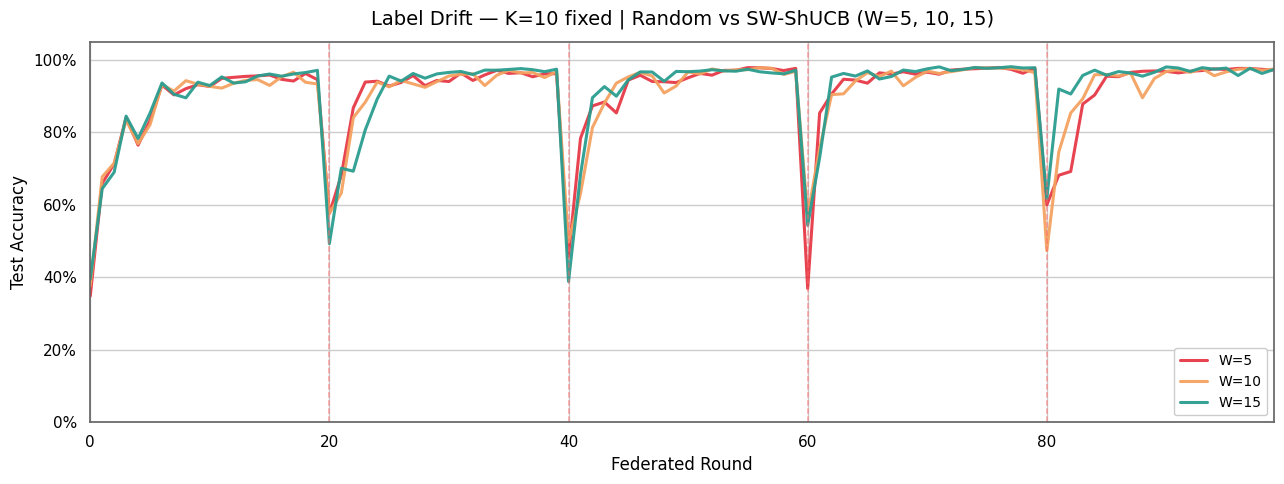

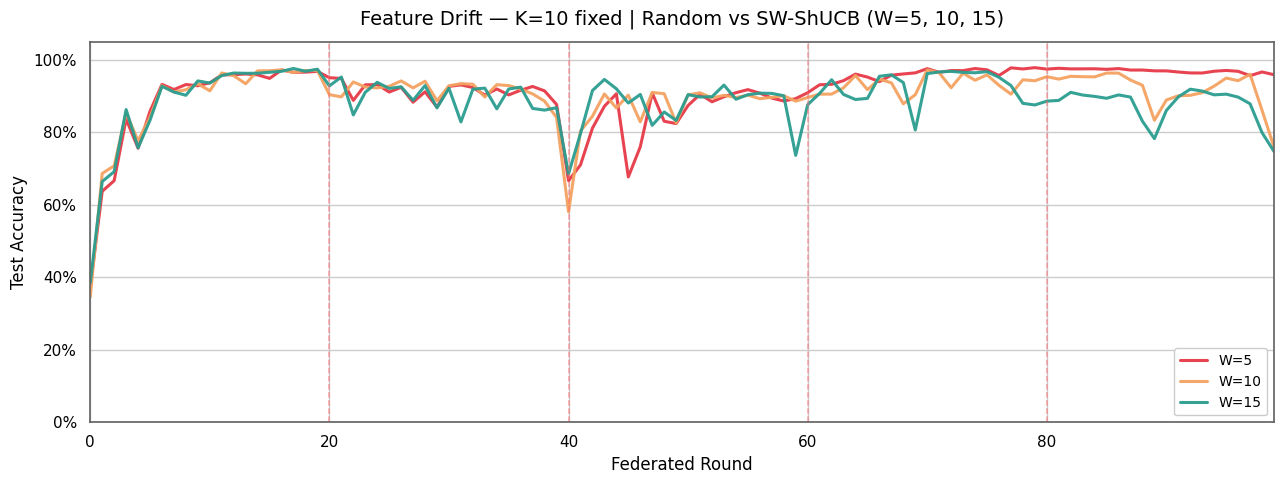

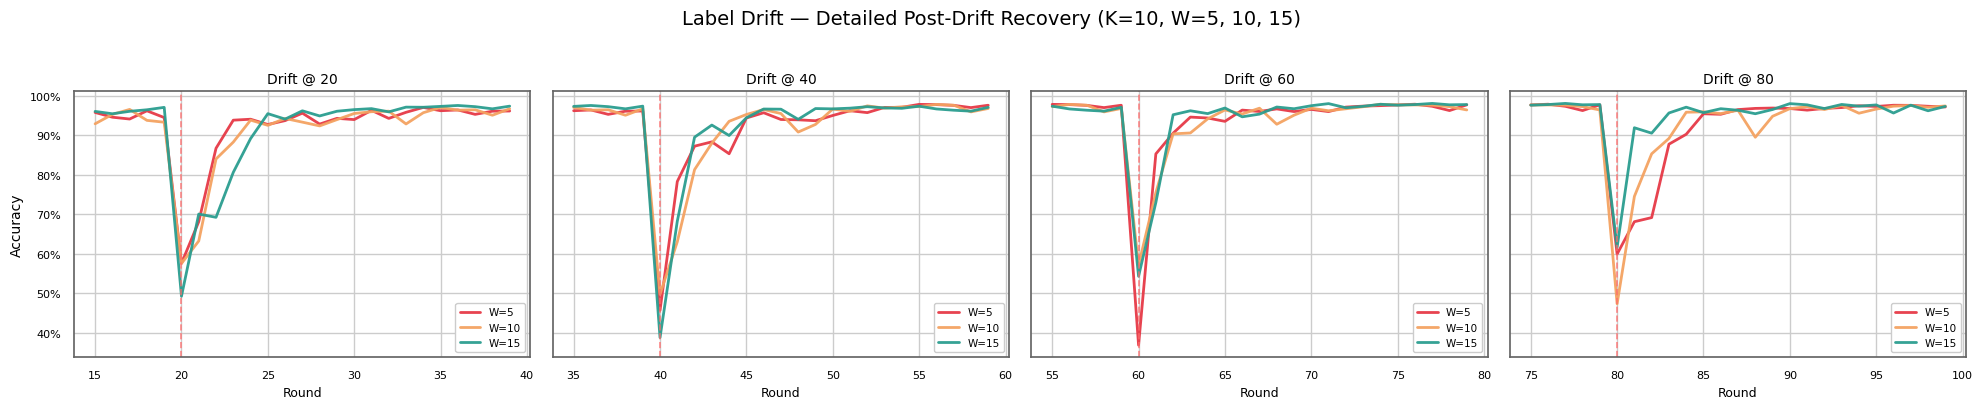

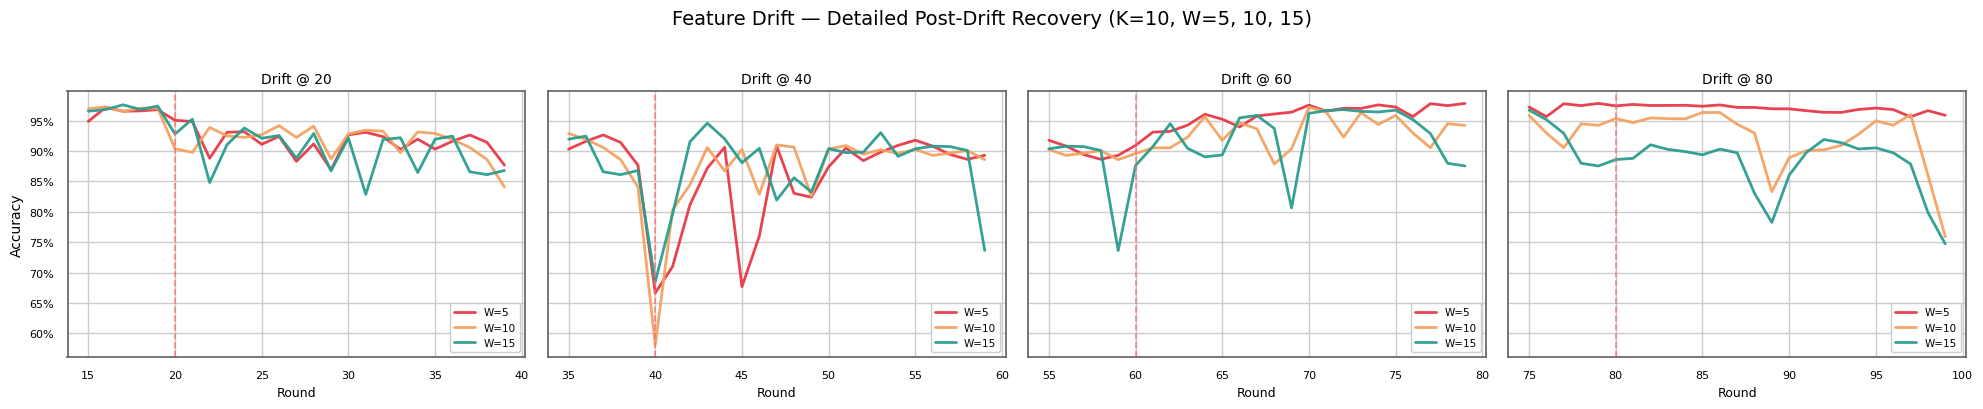

All requested plots saved to: /content/drive/MyDrive/SW_ShUCB_nonIID_checkpoints/plots


In [ ]:
# Generate the requested label-drift and feature-drift plots

def sanitize_results_for_plotting(results, num_rounds=NUM_ROUNDS):
    clean = {}
    for name, m in results.items():
        mm = dict(m)
        if 'accuracy' in mm and isinstance(mm['accuracy'], list):
            mm['accuracy'] = mm['accuracy'][:num_rounds]
        if 'round_time' in mm and isinstance(mm['round_time'], list):
            mm['round_time'] = mm['round_time'][:num_rounds]
        if 'comm_cost' in mm and isinstance(mm['comm_cost'], list):
            mm['comm_cost'] = mm['comm_cost'][:num_rounds]
        if 'comp_cost' in mm and isinstance(mm['comp_cost'], list):
            mm['comp_cost'] = mm['comp_cost'][:num_rounds]
        clean[name] = mm
    return clean

label_results = sanitize_results_for_plotting(label_results)
feature_results = sanitize_results_for_plotting(feature_results)

plot_accuracy_curves(
    label_results,
    drift_rounds=LABEL_DRIFT_ROUNDS,
    title='Label Drift — K=10 fixed | Random vs SW-ShUCB (W=5, 10, 15)',
    filename=str(PLOTS_DIR / 'label_drift_accuracy.png')
)

plot_accuracy_curves(
    feature_results,
    drift_rounds=FEATURE_DRIFT_ROUNDS,
    title='Feature Drift — K=10 fixed | Random vs SW-ShUCB (W=5, 10, 15)',
    filename=str(PLOTS_DIR / 'feature_drift_accuracy.png')
)

plot_recovery_zoom(
    label_results,
    drift_rounds=LABEL_DRIFT_ROUNDS,
    title='Label Drift — Detailed Post-Drift Recovery (K=10, W=5, 10, 15)',
    filename=str(PLOTS_DIR / 'label_drift_recovery_zoom.png')
)

plot_recovery_zoom(
    feature_results,
    drift_rounds=FEATURE_DRIFT_ROUNDS,
    title='Feature Drift — Detailed Post-Drift Recovery (K=10, W=5, 10, 15)',
    filename=str(PLOTS_DIR / 'feature_drift_recovery_zoom.png')
)

print("All requested plots saved to:", PLOTS_DIR)


In [ ]:
# Summary statistics

def post_drift_recovery_speed(acc_list, drift_rounds, threshold=0.80):
    """
    For each drift event, count how many rounds until accuracy
    crosses the threshold again. Returns the average recovery rounds.
    """
    speeds = []
    for dr in drift_rounds:
        recovered = None
        for r in range(dr, len(acc_list)):
            if acc_list[r] >= threshold:
                recovered = r - dr
                break
        speeds.append(recovered if recovered is not None else len(acc_list))
    return np.mean(speeds)


def rounds_to_first_target(acc_list, target=0.85):
    for r, a in enumerate(acc_list):
        if a >= target:
            return r
    return None


rows = []
for exp_name, results, drift_rounds in [
    ('Label Drift', label_results, LABEL_DRIFT_ROUNDS),
    ('Feature Drift', feature_results, FEATURE_DRIFT_ROUNDS)
]:
    for method, m in results.items():
        acc = m.get('accuracy', [])
        comm = m.get('comm_cost', [])
        comp = m.get('comp_cost', [])
        final_acc = acc[-1] if len(acc) else np.nan
        max_acc = max(acc) if len(acc) else np.nan
        rows.append({
            'Experiment'            : exp_name,
            'Method'                : method,
            'Final Acc (%)'         : f"{final_acc * 100:.2f}" if len(acc) else 'NA',
            'Max Acc (%)'           : f"{max_acc * 100:.2f}" if len(acc) else 'NA',
            'Rounds to 85%'         : rounds_to_first_target(acc, 0.85) or '>100',
            'Avg Recovery (rounds)' : f"{post_drift_recovery_speed(acc, drift_rounds):.1f}" if len(acc) else 'NA',
            'Total Comm Cost'       : comm[-1] if len(comm) else 'NA',
            'Total Comp Cost'       : comp[-1] if len(comp) else 'NA',
        })

df = pd.DataFrame(rows).sort_values(['Experiment', 'Method'])
print("\n" + "=" * 110)
print("QUANTITATIVE SUMMARY")
print("=" * 110)
print(df.to_string(index=False))
print("=" * 110)

save_dataframe(df, 'summary_metrics.csv')


def results_to_roundwise_dataframe(results, experiment_name):
    rows = []
    for method, m in results.items():
        acc = m.get('accuracy', [])
        rt = m.get('round_time', [])
        comm = m.get('comm_cost', [])
        comp = m.get('comp_cost', [])
        rounds = max(len(acc), len(rt), len(comm), len(comp))
        for r in range(rounds):
            rows.append({
                'Experiment': experiment_name,
                'Method': method,
                'Round': r,
                'Accuracy': acc[r] if r < len(acc) else np.nan,
                'Round Time': rt[r] if r < len(rt) else np.nan,
                'Comm Cost': comm[r] if r < len(comm) else np.nan,
                'Comp Cost': comp[r] if r < len(comp) else np.nan,
            })
    return pd.DataFrame(rows)

roundwise_df = pd.concat([
    results_to_roundwise_dataframe(label_results, 'Label Drift'),
    results_to_roundwise_dataframe(feature_results, 'Feature Drift')
], ignore_index=True)

save_dataframe(roundwise_df, 'roundwise_accuracy_results.csv')
print("\n" + "=" * 110)
print("ROUND-WISE RESULTS CSV SAVED: roundwise_accuracy_results.csv")
print("=" * 110)



QUANTITATIVE SUMMARY
   Experiment Method Final Acc (%) Max Acc (%)  Rounds to 85% Avg Recovery (rounds)  Total Comm Cost  Total Comp Cost
Feature Drift   W=10         75.91       97.25              3                   0.2             1000             3000
Feature Drift   W=15         74.71       97.60              3                   0.5             1000             3000
Feature Drift    W=5         95.88       97.83              5                   0.5             1000             3000
  Label Drift   W=10         97.45       97.88              6                   2.0             1000             3000
  Label Drift   W=15         97.33       98.09              5                   2.0             1000             3000
  Label Drift    W=5         97.19       97.89              6                   2.0             1000             3000
Saved table to /content/drive/MyDrive/SW_ShUCB_nonIID_checkpoints/results/summary_metrics.csv
Saved table to /content/drive/MyDrive/SW_ShUCB_nonIID_chec

In [ ]:
# Print round-wise accuracies in the requested log-style format

def print_roundwise_log(experiment_name, results):
    print("\n" + "=" * 110)
    print(f"{experiment_name.upper()} | ROUND-WISE ACCURACY LOG")
    print("=" * 110)
    for method, m in results.items():
        acc = m.get('accuracy', [])
        rt = m.get('round_time', [])
        comm = m.get('comm_cost', [])
        comp = m.get('comp_cost', [])
        print(f"\n--- {method} ---")
        for r in range(len(acc)):
            rt_str = f"{rt[r]:.1f}s" if r < len(rt) and rt[r] is not None else "NA"
            comm_str = f"{comm[r]}" if r < len(comm) and comm[r] is not None else "NA"
            comp_str = f"{comp[r]}" if r < len(comp) and comp[r] is not None else "NA"
            print(
                f"round {r:03d}/{len(acc):03d} | "
                f"accuracy={acc[r]:.4f} | "
                f"time={rt_str} | "
                f"comm_cost={comm_str} | "
                f"comp_cost={comp_str}"
            )

print_roundwise_log("Label Drift", label_results)
print_roundwise_log("Feature Drift", feature_results)



LABEL DRIFT | ROUND-WISE ACCURACY LOG

--- W=5 ---
round 000/100 | accuracy=0.3480 | time=135.9s | comm_cost=10 | comp_cost=30
round 001/100 | accuracy=0.6589 | time=126.4s | comm_cost=20 | comp_cost=60
round 002/100 | accuracy=0.7133 | time=128.0s | comm_cost=30 | comp_cost=90
round 003/100 | accuracy=0.8409 | time=126.4s | comm_cost=40 | comp_cost=120
round 004/100 | accuracy=0.7644 | time=127.3s | comm_cost=50 | comp_cost=150
round 005/100 | accuracy=0.8327 | time=127.8s | comm_cost=60 | comp_cost=180
round 006/100 | accuracy=0.9302 | time=125.9s | comm_cost=70 | comp_cost=210
round 007/100 | accuracy=0.9032 | time=128.9s | comm_cost=80 | comp_cost=240
round 008/100 | accuracy=0.9204 | time=129.3s | comm_cost=90 | comp_cost=270
round 009/100 | accuracy=0.9312 | time=128.1s | comm_cost=100 | comp_cost=300
round 010/100 | accuracy=0.9263 | time=129.2s | comm_cost=110 | comp_cost=330
round 011/100 | accuracy=0.9487 | time=127.9s | comm_cost=120 | comp_cost=360
round 012/100 | accuracy